In [1]:
import polars as pl
import numpy as np
from util import plot_distribution_grid

In [2]:
#Load data

trips = pl.read_csv("../Data/trips.txt")

# Match join key types.
trips = trips.with_columns(
    pl.col("trip_id").cast(pl.Utf8),
    pl.col("route_id").cast(pl.Utf8),
)

routes = pl.read_csv("../Data/routes.txt")
routes = routes.with_columns(pl.col("route_id").cast(pl.Utf8))

updates = pl.read_parquet("../Data/final_trip_updates.parquet")

df = (
    updates
    .drop("route_id")
    .join(trips.select(["trip_id", "route_id"]), on="trip_id", how="left")
    .join(routes, on="route_id", how="left")
)

df.head()


provider,service_date,entity_id,vehicle_id,trip_id,stop_id,current_stop_sequence,timestamp,source,timestamp_utc,trip_start_date,trip_start_time,trip_schedule_relationship,trip_direction_id,stop_time_update_schedule_relationship,arrival_time,arrival_delay,arrival_time_utc,departure_time,departure_delay,departure_time_utc,stop_time_uncertainty,route_id,agency_id,route_short_name,route_long_name,route_type,route_desc
str,str,str,str,str,str,i64,i64,str,"datetime[μs, UTC]",str,str,i64,i64,i64,i64,i64,"datetime[μs, UTC]",i64,i64,"datetime[μs, UTC]",i64,str,i64,str,str,i64,str
"""otraf""","""2026-03-25""","""55700501354264604""","""9031005920505667""","""55700000081154342""","""9022005001445001""",9,1774434860,"""otraf:TripUpdates:2026-03-25:1…",2026-03-25 10:34:20 UTC,"""20260325""",null,0,null,null,1774434281,208,2026-03-25 10:24:41 UTC,1774434281,208,2026-03-25 10:24:41 UTC,0,"""9011005021600000""",55700000000001407,"""16""",null,700,null
"""otraf""","""2026-03-25""","""55700501338946756""","""9031005920804453""","""55700000081915075""","""9022005002977002""",10,1774456108,"""otraf:TripUpdates:2026-03-25:1…",2026-03-25 16:28:28 UTC,"""20260325""",null,0,null,null,1774455899,-48,2026-03-25 16:24:59 UTC,1774455899,-48,2026-03-25 16:24:59 UTC,0,"""9011005057100000""",55700000000001407,"""571""",null,700,null
"""otraf""","""2026-03-25""","""55700501353130488""","""9031005920505667""","""55700000074062872""","""9022005000417002""",3,1774456560,"""otraf:TripUpdates:2026-03-25:1…",2026-03-25 16:36:00 UTC,"""20260325""",null,0,null,null,1774455987,185,2026-03-25 16:26:27 UTC,1774455987,185,2026-03-25 16:26:27 UTC,0,"""9011005021200000""",55700000000001407,"""12""",null,700,null
"""otraf""","""2026-03-25""","""55700501368800571""","""9031005900306728""","""55700000081790239""","""9022005001365002""",3,1774449046,"""otraf:TripUpdates:2026-03-25:1…",2026-03-25 14:30:46 UTC,"""20260325""",null,0,null,null,1774448476,14,2026-03-25 14:21:16 UTC,1774448476,14,2026-03-25 14:21:16 UTC,0,"""9011005011000000""",55700000000001407,"""10""",null,700,null
"""otraf""","""2026-03-25""","""55700501373595814""","""9031005920703872""","""55700000082915796""","""9022005000038002""",9,1774466509,"""otraf:TripUpdates:2026-03-25:2…",2026-03-25 19:21:49 UTC,"""20260325""",null,0,null,null,1774465926,6,2026-03-25 19:12:06 UTC,1774465926,6,2026-03-25 19:12:06 UTC,0,"""9011005004000000""",55700000000001407,"""40""",null,700,null


In [3]:
# Find groups with the most observations and their average arrival delay
most_observed_trip_stop = (
    df.group_by(["route_id", "route_short_name", "stop_id"])
    .agg(
        pl.len().alias("observation_count"),
        pl.col("arrival_delay").mean().alias("avg_arrival_delay"),
    )
    .filter(pl.col("avg_arrival_delay") > 0)
    .sort("observation_count", descending=True)
    .head(100)
)

most_observed_trip_stop

route_id,route_short_name,stop_id,observation_count,avg_arrival_delay
str,str,str,u32,f64
"""9011005011100000""","""11""","""9022005001087001""",119,19.07563
"""9011005011100000""","""11""","""9022005001088001""",119,17.87395
"""9011005011100000""","""11""","""9022005001085001""",119,30.386555
"""9011005000200000""","""2""","""9022005001019017""",101,97.960396
"""9011005000300000""","""3""","""9022005081020001""",101,121.247525
…,…,…,…,…
"""9011005020100000""","""1""","""9022005001227001""",86,149.011628
"""9011005020100000""","""1""","""9022005001232001""",86,103.523256
"""9011005020100000""","""1""","""9022005000042001""",86,73.081395


### Arrival delay distribution | route_id=9011005011100000, stop_id=9022005001085001

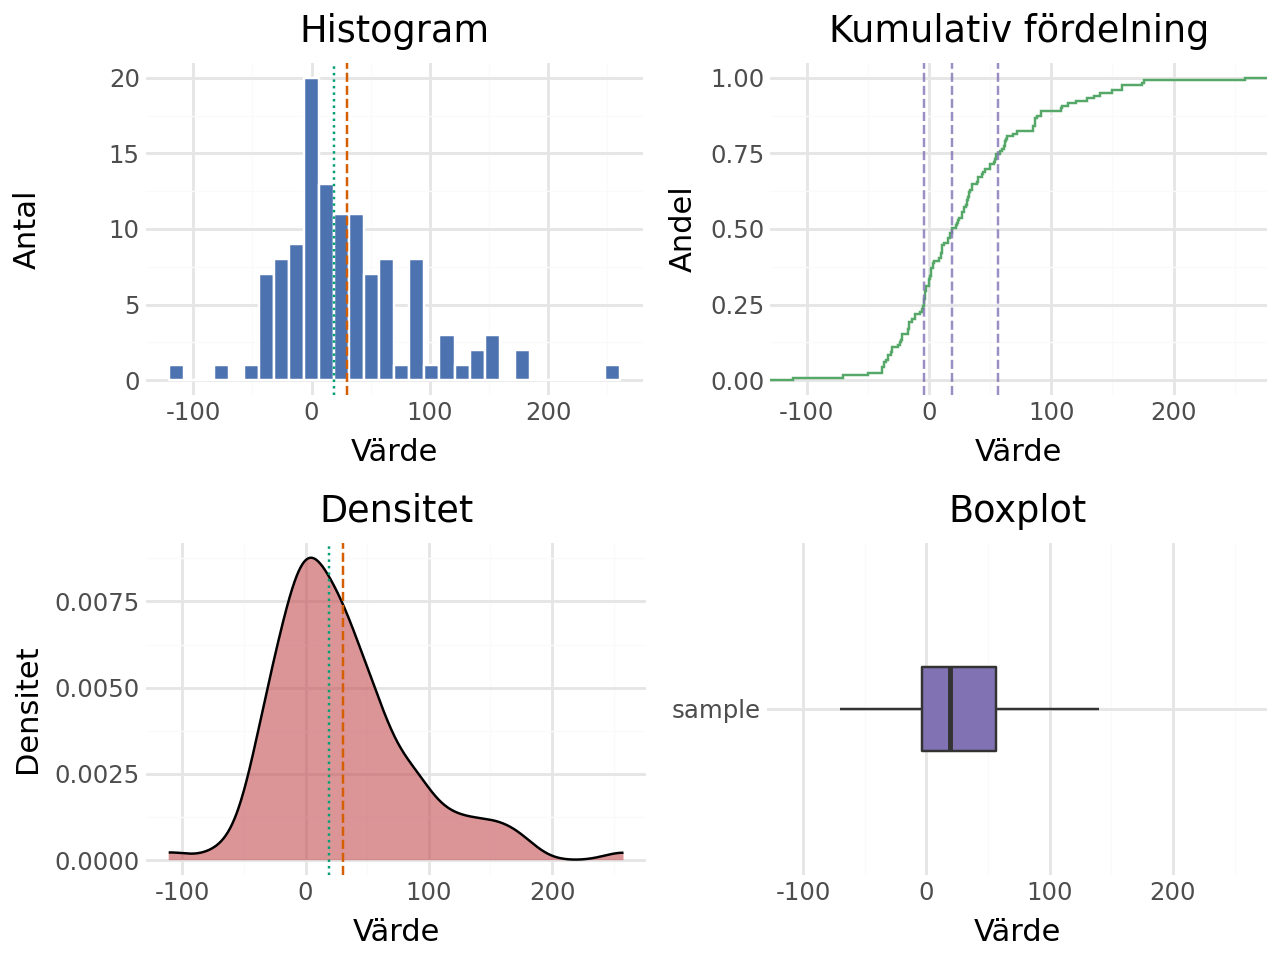

In [4]:
# Plot distribution of arrival_delay for a chosen route_id and stop_id (ggplot2-like style)


route_id_value = "9011005011100000"
stop_id_value = "9022005001085001"

plot_df = (
    df.filter(
        (pl.col("route_id") == route_id_value)
        & (pl.col("stop_id") == stop_id_value)
        & pl.col("arrival_delay").is_not_null()
    )
    .select("arrival_delay")
    .to_pandas()
)

plot_distribution_grid(
    title=f"Arrival delay distribution | route_id={route_id_value}, stop_id={stop_id_value}",
    data_sample=plot_df["arrival_delay"]
)


Normalfordelad data -> medelvarde: 0.941, standardavvikelse: 3.000


### Normalfördelad data

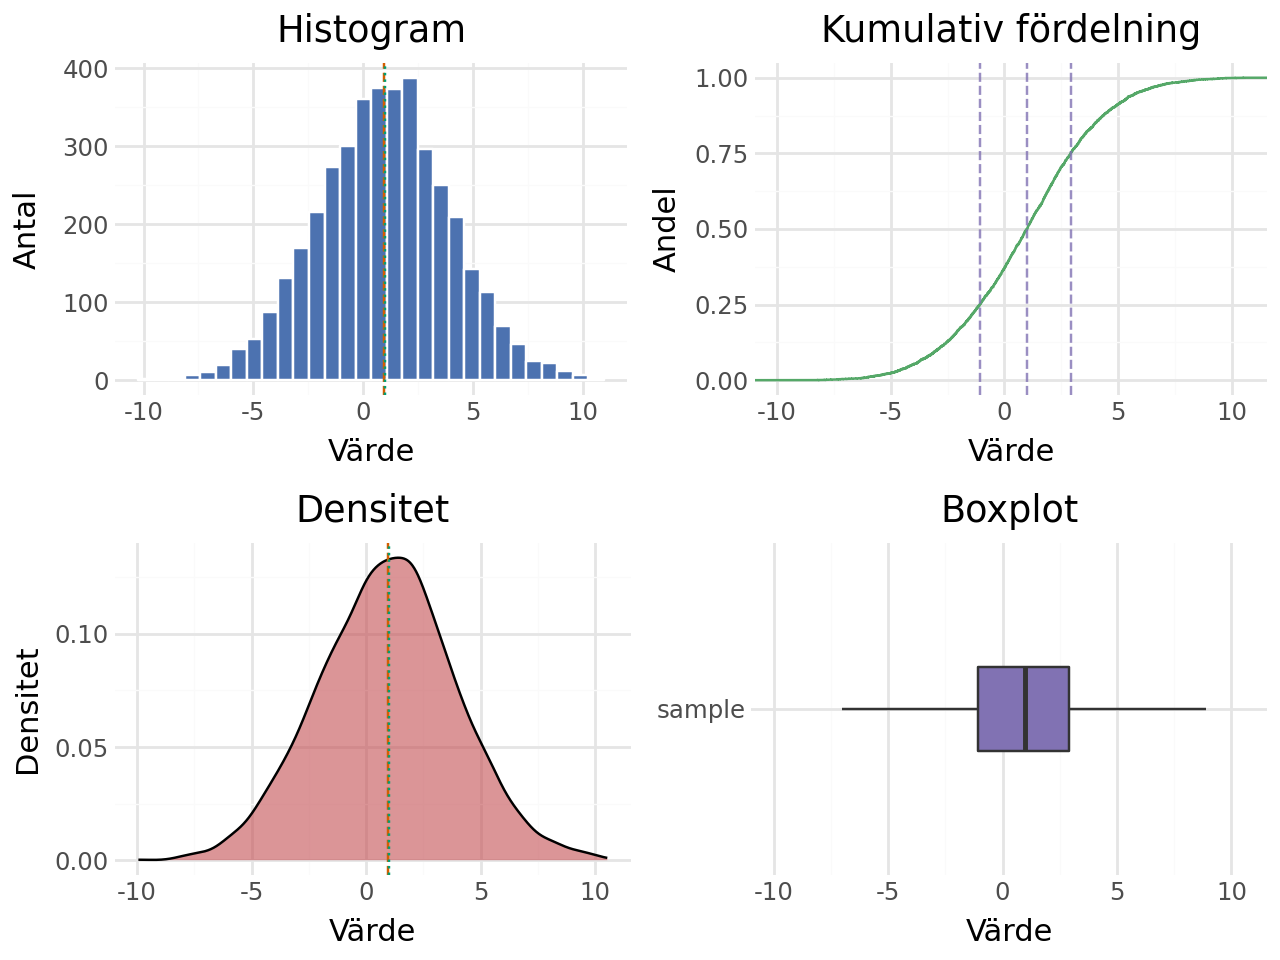

In [5]:
# Exempel 1: Normalfordelad data med medelvarde 1
rng = np.random.default_rng(42)
normal_data = rng.normal(loc=1, scale=3, size=4000)
print(f"Normalfordelad data -> medelvarde: {normal_data.mean():.3f}, standardavvikelse: {normal_data.std(ddof=1):.3f}")
plot_distribution_grid("Normalfördelad data", normal_data)

Lognormalfordelad data -> medelvarde: 1.001, standardavvikelse: 0.363


### Lognormalfordelad data

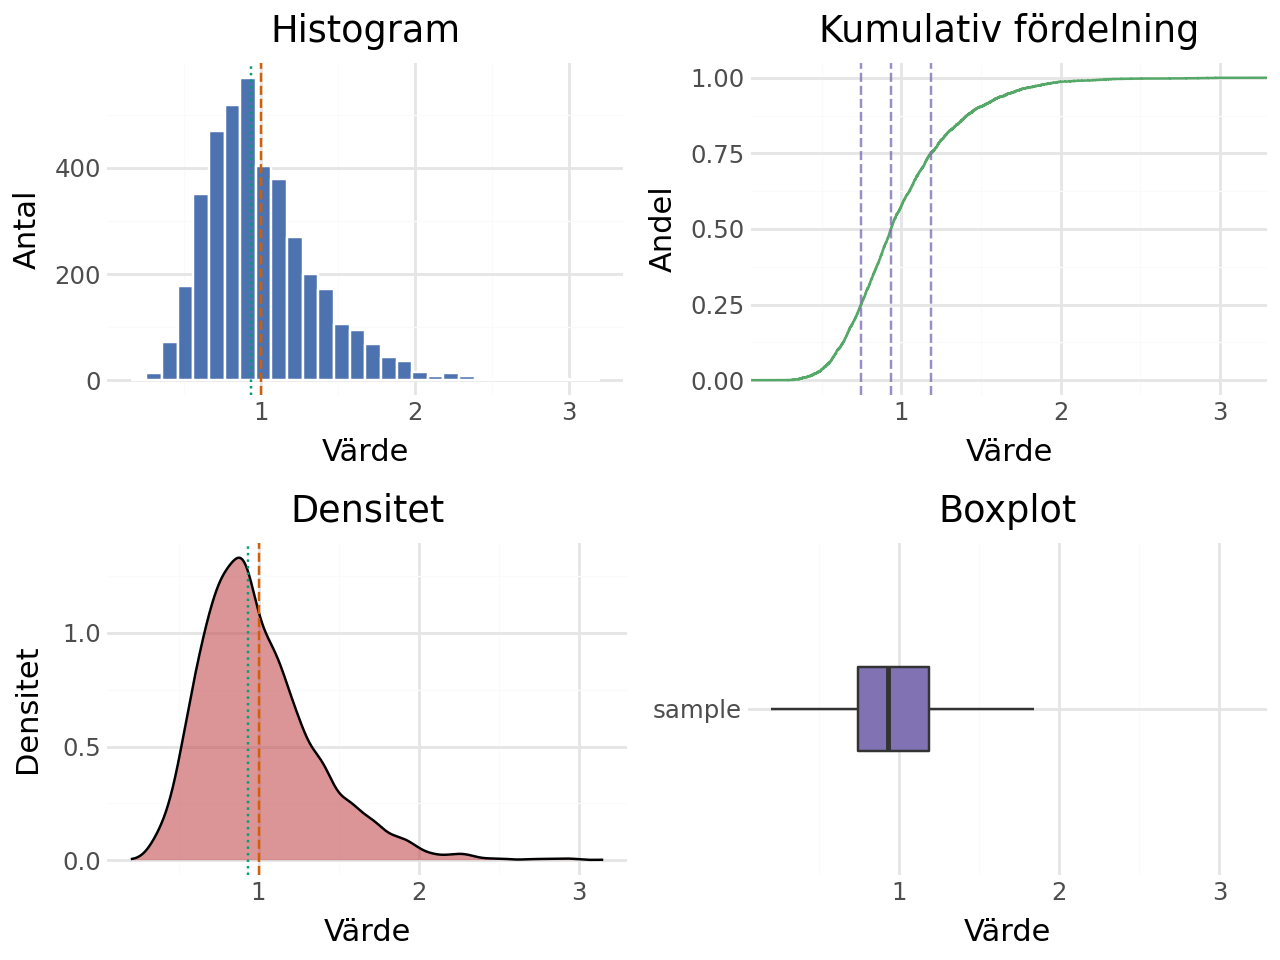

In [6]:
# Exempel 2: Lognormalfordelad data (hogerskev) med medelvarde 1 och mindre spridning
sigma = 0.35
mu = -(sigma**2) / 2
lognormal_data = rng.lognormal(mean=mu, sigma=sigma, size=4000)
print(f"Lognormalfordelad data -> medelvarde: {lognormal_data.mean():.3f}, standardavvikelse: {lognormal_data.std(ddof=1):.3f}")
plot_distribution_grid("Lognormalfordelad data", lognormal_data)

Likformigt fordelad data -> medelvarde: 0.999, standardavvikelse: 0.576


### Likformigt fordelad data

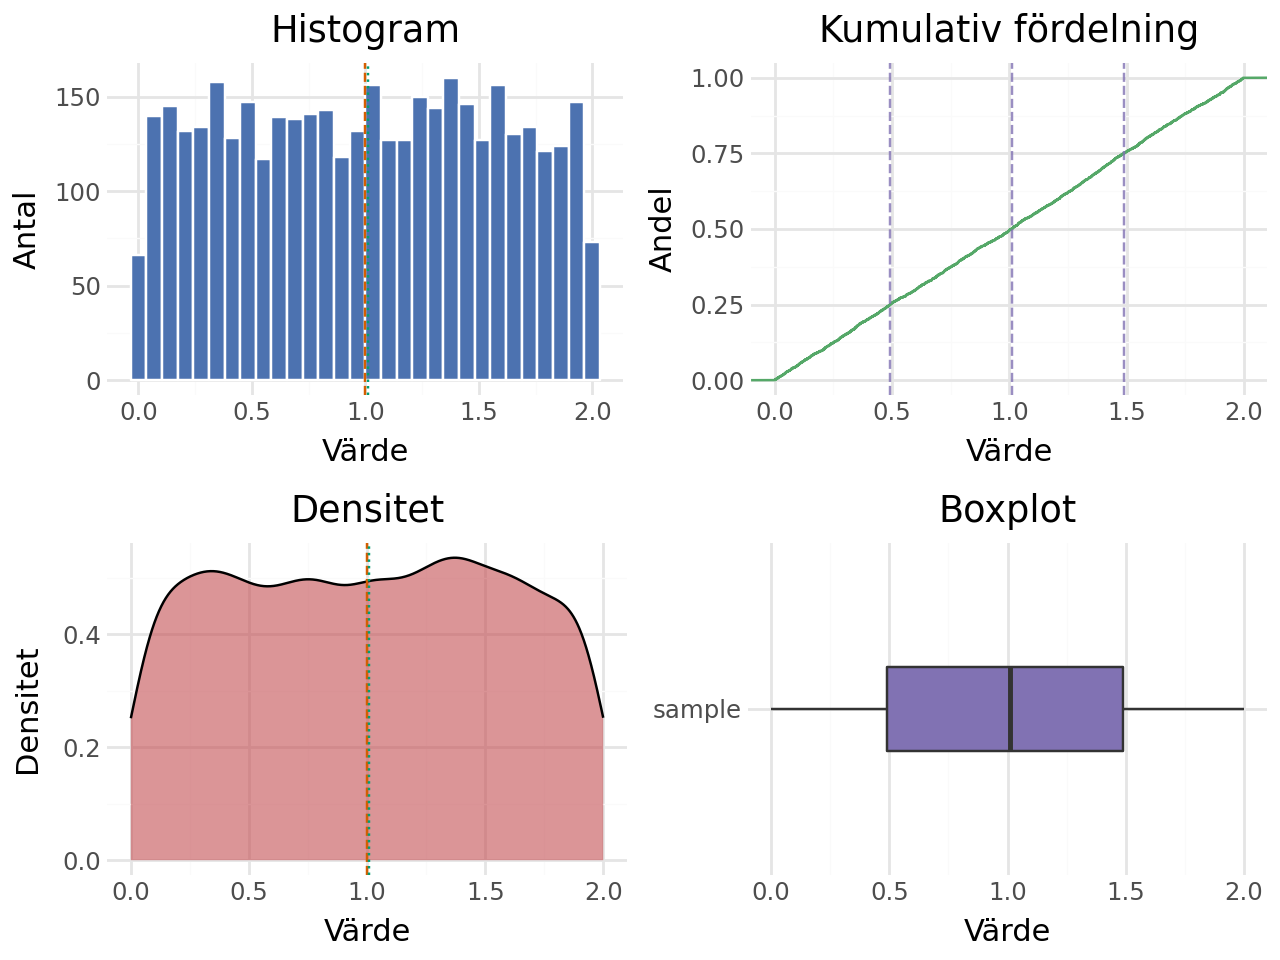

In [7]:
# Exempel 3: Likformigt fordelad data med medelvarde 1
uniform_data = rng.uniform(0, 2, size=4000)
print(f"Likformigt fordelad data -> medelvarde: {uniform_data.mean():.3f}, standardavvikelse: {uniform_data.std(ddof=1):.3f}")
plot_distribution_grid("Likformigt fordelad data", uniform_data)